In [1]:
import pandas as pd
from pathlib import Path

# Set base directory
BASE_DIR = Path("..")

# Define input paths
DATA_PATH = BASE_DIR / "output" / "dataset_no0min.csv"
INSPECTION_PLAYERS_PATH = BASE_DIR / "data" / "Players for inspection.csv"

# Define and create output directory
OUT_DIR = BASE_DIR / "output"
OUT_DIR.mkdir(exist_ok=True)
OUT_PATH = OUT_DIR / "inspection_data_2025_26.csv"

print("Loading datasets...")

# Load data
df = pd.read_csv(DATA_PATH, encoding="utf-8-sig")
players_inspect = pd.read_csv(INSPECTION_PLAYERS_PATH, encoding="utf-8-sig")

# Filter for the correct season
SEASON_TO_FILTER = "2025-26" 
if SEASON_TO_FILTER not in df["season"].unique():
    SEASON_TO_FILTER = df["season"].dropna().max()
    print(f"Falling back to season: {SEASON_TO_FILTER}")
    
df_filtered = df[df["season"] == SEASON_TO_FILTER].copy()

# --- THE COLLISION-PROOF MERGE FIX ---
# We will merge on BOTH names to ensure uniqueness, ignoring the mismatched UUIDs.
merge_keys = ["Player Name", "Web Name"]

# 1. Clean the text columns (lowercase and strip spaces) to guarantee perfect matches
for col in merge_keys:
    if col in df_filtered.columns and col in players_inspect.columns:
        df_filtered[col] = df_filtered[col].astype(str).str.strip().str.lower()
        players_inspect[col] = players_inspect[col].astype(str).str.strip().str.lower()

# 2. Drop the generated UUIDs from the inspection dataframe so they don't corrupt the main data
players_inspect_clean = players_inspect.drop(columns=["Player UUID", "season", "id"], errors="ignore")

# 3. Perform the safe merge
df_filtered_inspection = df_filtered.merge(
    players_inspect_clean,
    on=merge_keys,
    how="inner"
)

# Restore original capitalization for readability
df_filtered_inspection["Player Name"] = df_filtered_inspection["Player Name"].str.title()
df_filtered_inspection["Web Name"] = df_filtered_inspection["Web Name"].str.title()

print(f"\nRows after safe Name-based merge: {len(df_filtered_inspection):,}")
print(f"Unique players successfully matched: {df_filtered_inspection['Web Name'].nunique()}")

if len(df_filtered_inspection) == 0:
    raise ValueError("Merge failed! Even the names do not match between the files. Check the 'Players for inspection.csv' contents.")

# Sort values for clean output
df_filtered_inspection = df_filtered_inspection.sort_values(
    ["Player Name", "Gameweek"]
).reset_index(drop=True)

# Save the final filtered dataset
df_filtered_inspection.to_csv(OUT_PATH, index=False, encoding="utf-8-sig")
print(f"Saved inspection dataset to: {OUT_PATH}")

Loading datasets...

Rows after safe Name-based merge: 385
Unique players successfully matched: 12
Saved inspection dataset to: ..\output\inspection_data_2025_26.csv


In [2]:
def update_model_performance(model_name, mae_train, mae_val, rmse_train, rmse_val):
    perf_path = Path("../output/models/models_performance.csv")
    
    new_row = pd.DataFrame([{
        "Model": model_name,
        "MAE_Train": round(mae_train, 4),
        "MAE_Validation": round(mae_val, 4),
        "RMSE_Train": round(rmse_train, 4),
        "RMSE_Validation": round(rmse_val, 4),
        "Improvement_vs_Baseline (%)": 0.0
    }])

    if perf_path.exists():
        perf_df = pd.read_csv(perf_path)
        
        
        
        perf_df = perf_df[perf_df["Model"] != model_name].copy()
        
        #Improvement = {MAE_{Baseline} - MAE_{Model}}/{MAE_{Baseline} x 100%
        baseline_row = perf_df[perf_df["Model"].str.contains("Rolling Average", na=False)]
        
        if not baseline_row.empty and "Rolling Average" not in model_name:
            baseline_mae = baseline_row.iloc[0]["MAE_Validation"]
            improvement = ((baseline_mae - mae_val) / baseline_mae) * 100
            new_row.loc[0, "Improvement_vs_Baseline (%)"] = round(improvement, 2)
            
        # Προσθήκη της ενημερωμένης γραμμής
        perf_df = pd.concat([perf_df, new_row], ignore_index=True)
    else:
        perf_df = new_row
        perf_path.parent.mkdir(parents=True, exist_ok=True)

    
    perf_df.to_csv(perf_path, index=False, encoding="utf-8-sig")
    print(f" model_performance.csv updated (Overwrite): {model_name}")
    return perf_df

In [3]:

DATA_PATH = Path("..") / "output" / "inspection_data_2025_26.csv"

print("Loading inspection dataset...")

df = pd.read_csv(DATA_PATH, encoding="utf-8-sig")

print(f"Rows: {len(df):,}")
print(f"Players: {df['Player UUID'].nunique():,}")
print(f"Gameweeks range: {df['Gameweek'].min()} to {df['Gameweek'].max()}")

df = df.sort_values(["Player UUID", "Gameweek"]).reset_index(drop=True)

df.head()


Loading inspection dataset...
Rows: 385
Players: 12
Gameweeks range: 1 to 35


,Player UUID,Code,Player Name,Web Name,Player Team Name,season,Gameweek,Minutes Played,Goals Scored,Assists,...,Avg_Influence_L3,Avg_Total Points_L5,Avg_Minutes Played_L5,Avg_Goals Scored_L5,Avg_Assists_L5,Avg_Goals Conceded_L5,Avg_ICT Index_L5,Avg_Threat_L5,Avg_Creativity_L5,Avg_Influence_L5
0,07b1aec4-7863-4b02-a1a3-8503cb4736e3,260,Marc Guéhi,Guéhi,Man City,2025-26,1,90,0,0,...,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
1,07b1aec4-7863-4b02-a1a3-8503cb4736e3,260,Marc Guéhi,Guéhi,Man City,2025-26,2,90,0,0,...,13.800000,6.000000,90.0,0.000000,0.0,0.000000,2.600000,2.000000,10.000000,13.800000
2,07b1aec4-7863-4b02-a1a3-8503cb4736e3,260,Marc Guéhi,Guéhi,Man City,2025-26,3,90,1,0,...,12.500000,4.000000,90.0,0.000000,0.0,0.500000,2.150000,3.000000,5.750000,12.500000
3,07b1aec4-7863-4b02-a1a3-8503cb4736e3,260,Marc Guéhi,Guéhi,Man City,2025-26,4,90,0,0,...,26.266667,7.666667,90.0,0.333333,0.0,0.333333,3.866667,7.666667,4.433333,26.266667
4,07b1aec4-7863-4b02-a1a3-8503cb4736e3,260,Marc Guéhi,Guéhi,Man City,2025-26,5,90,0,1,...,27.466667,7.250000,90.0,0.250000,0.0,0.250000,3.725000,6.750000,6.275000,24.050000


In [4]:


print("Creating Target_NextGW...")

df["Target_NextGW"] = (
    df.groupby("Player UUID")["Total Points"]
      .shift(-1)
)

rows_before = len(df)

df = df.dropna(subset=["Target_NextGW"]).reset_index(drop=True)

rows_after = len(df)

df["Target_NextGW"] = df["Target_NextGW"].astype(float)

print(f"Rows before target drop: {rows_before}")
print(f"Rows after target drop:  {rows_after}")
print(f"Removed rows (last GW per player): {rows_before - rows_after}")

print("Remaining GW range:",
      df["Gameweek"].min(),
      "to",
      df["Gameweek"].max())

df.head()


Creating Target_NextGW...
Rows before target drop: 385
Rows after target drop:  373
Removed rows (last GW per player): 12
Remaining GW range: 1 to 34


,Player UUID,Code,Player Name,Web Name,Player Team Name,season,Gameweek,Minutes Played,Goals Scored,Assists,...,Avg_Total Points_L5,Avg_Minutes Played_L5,Avg_Goals Scored_L5,Avg_Assists_L5,Avg_Goals Conceded_L5,Avg_ICT Index_L5,Avg_Threat_L5,Avg_Creativity_L5,Avg_Influence_L5,Target_NextGW
0,07b1aec4-7863-4b02-a1a3-8503cb4736e3,260,Marc Guéhi,Guéhi,Man City,2025-26,1,90,0,0,...,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,2.0
1,07b1aec4-7863-4b02-a1a3-8503cb4736e3,260,Marc Guéhi,Guéhi,Man City,2025-26,2,90,0,0,...,6.000000,90.0,0.000000,0.0,0.000000,2.600000,2.000000,10.000000,13.800000,15.0
2,07b1aec4-7863-4b02-a1a3-8503cb4736e3,260,Marc Guéhi,Guéhi,Man City,2025-26,3,90,1,0,...,4.000000,90.0,0.000000,0.0,0.500000,2.150000,3.000000,5.750000,12.500000,6.0
3,07b1aec4-7863-4b02-a1a3-8503cb4736e3,260,Marc Guéhi,Guéhi,Man City,2025-26,4,90,0,0,...,7.666667,90.0,0.333333,0.0,0.333333,3.866667,7.666667,4.433333,26.266667,7.0
4,07b1aec4-7863-4b02-a1a3-8503cb4736e3,260,Marc Guéhi,Guéhi,Man City,2025-26,5,90,0,1,...,7.250000,90.0,0.250000,0.0,0.250000,3.725000,6.750000,6.275000,24.050000,7.0


In [5]:
print("Creating time-based train / validation split...")

df["Split"] = "Train"

df.loc[df["Gameweek"] == 10, "Split"] = "Validation"

print(df["Split"].value_counts())

print("\nValidation rows (should be only GW10):")
print(df[df["Split"] == "Validation"][["Player UUID", "Gameweek"]].head())

df.head()


Creating time-based train / validation split...
Split
Train         361
Validation     12
Name: count, dtype: int64

Validation rows (should be only GW10):
                              Player UUID  Gameweek
9    07b1aec4-7863-4b02-a1a3-8503cb4736e3        10
39   190af802-a151-4d37-addc-7a9bf94cdcc5        10
71   4b70707a-1215-4167-8f72-9d07e46df80f        10
106  4e4feb71-3408-4744-9129-ab58596551d4        10
133  6378ff9f-972e-44ba-9217-971fd514834a        10


,Player UUID,Code,Player Name,Web Name,Player Team Name,season,Gameweek,Minutes Played,Goals Scored,Assists,...,Avg_Minutes Played_L5,Avg_Goals Scored_L5,Avg_Assists_L5,Avg_Goals Conceded_L5,Avg_ICT Index_L5,Avg_Threat_L5,Avg_Creativity_L5,Avg_Influence_L5,Target_NextGW,Split
0,07b1aec4-7863-4b02-a1a3-8503cb4736e3,260,Marc Guéhi,Guéhi,Man City,2025-26,1,90,0,0,...,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,2.0,Train
1,07b1aec4-7863-4b02-a1a3-8503cb4736e3,260,Marc Guéhi,Guéhi,Man City,2025-26,2,90,0,0,...,90.0,0.000000,0.0,0.000000,2.600000,2.000000,10.000000,13.800000,15.0,Train
2,07b1aec4-7863-4b02-a1a3-8503cb4736e3,260,Marc Guéhi,Guéhi,Man City,2025-26,3,90,1,0,...,90.0,0.000000,0.0,0.500000,2.150000,3.000000,5.750000,12.500000,6.0,Train
3,07b1aec4-7863-4b02-a1a3-8503cb4736e3,260,Marc Guéhi,Guéhi,Man City,2025-26,4,90,0,0,...,90.0,0.333333,0.0,0.333333,3.866667,7.666667,4.433333,26.266667,7.0,Train
4,07b1aec4-7863-4b02-a1a3-8503cb4736e3,260,Marc Guéhi,Guéhi,Man City,2025-26,5,90,0,1,...,90.0,0.250000,0.0,0.250000,3.725000,6.750000,6.275000,24.050000,7.0,Train


In [6]:
print("Computing rolling average baseline (window = 3)...")

ROLLING_WINDOW = 3

df["Rolling_Pred"] = (
    df.groupby("Player UUID")["Total Points"]
      .transform(lambda s: s.rolling(ROLLING_WINDOW, min_periods=1).mean())
)

df["Prediction_GW"] = df["Gameweek"] + 1

print(df[[
    "Player UUID",
    "Gameweek",
    "Prediction_GW",
    "Total Points",
    "Rolling_Pred",
    "Target_NextGW"
]].head(10))


Computing rolling average baseline (window = 3)...
                            Player UUID  Gameweek  Prediction_GW  \
0  07b1aec4-7863-4b02-a1a3-8503cb4736e3         1              2   
1  07b1aec4-7863-4b02-a1a3-8503cb4736e3         2              3   
2  07b1aec4-7863-4b02-a1a3-8503cb4736e3         3              4   
3  07b1aec4-7863-4b02-a1a3-8503cb4736e3         4              5   
4  07b1aec4-7863-4b02-a1a3-8503cb4736e3         5              6   
5  07b1aec4-7863-4b02-a1a3-8503cb4736e3         6              7   
6  07b1aec4-7863-4b02-a1a3-8503cb4736e3         7              8   
7  07b1aec4-7863-4b02-a1a3-8503cb4736e3         8              9   
8  07b1aec4-7863-4b02-a1a3-8503cb4736e3         9             10   
9  07b1aec4-7863-4b02-a1a3-8503cb4736e3        10             11   

   Total Points  Rolling_Pred  Target_NextGW  
0             6      6.000000            2.0  
1             2      4.000000           15.0  
2            15      7.666667            6.0  
3           

In [7]:
import numpy as np

print("Defining Train / Validation split based on Prediction_GW...")

df["Split"] = "Train"
df.loc[df["Prediction_GW"].isin([10, 11]), "Split"] = "Validation"

print(df["Split"].value_counts())

print("\nValidation check (Prediction_GW should be 10 or 11):")
print(
    df[df["Split"] == "Validation"][
        ["Player UUID", "Gameweek", "Prediction_GW"]
    ].head(10)
)

print("\nComputing errors for rolling baseline...")

df["Error_Rolling"] = (
    df["Target_NextGW"] - df["Rolling_Pred"]
).abs()

mae_train = df[df["Split"] == "Train"]["Error_Rolling"].mean()
mae_val   = df[df["Split"] == "Validation"]["Error_Rolling"].mean()

rmse_train = np.sqrt(
    np.mean(
        (df[df["Split"] == "Train"]["Target_NextGW"]
         - df[df["Split"] == "Train"]["Rolling_Pred"]) ** 2
    )
)

rmse_val = np.sqrt(
    np.mean(
        (df[df["Split"] == "Validation"]["Target_NextGW"]
         - df[df["Split"] == "Validation"]["Rolling_Pred"]) ** 2
    )
)

print("\nRolling Average Baseline Performance:")
print(f"MAE Train: {mae_train:.4f}")
print(f"MAE Validation: {mae_val:.4f}")
print(f"RMSE Train: {rmse_train:.4f}")
print(f"RMSE Validation: {rmse_val:.4f}")


update_model_performance(
    model_name="Rolling Average (window=3)", 
    mae_train=mae_train, 
    mae_val=mae_val, 
    rmse_train=rmse_train, 
    rmse_val=rmse_val
)

Defining Train / Validation split based on Prediction_GW...
Split
Train         350
Validation     23
Name: count, dtype: int64

Validation check (Prediction_GW should be 10 or 11):
                              Player UUID  Gameweek  Prediction_GW
8    07b1aec4-7863-4b02-a1a3-8503cb4736e3         9             10
9    07b1aec4-7863-4b02-a1a3-8503cb4736e3        10             11
38   190af802-a151-4d37-addc-7a9bf94cdcc5         9             10
39   190af802-a151-4d37-addc-7a9bf94cdcc5        10             11
70   4b70707a-1215-4167-8f72-9d07e46df80f         9             10
71   4b70707a-1215-4167-8f72-9d07e46df80f        10             11
105  4e4feb71-3408-4744-9129-ab58596551d4         9             10
106  4e4feb71-3408-4744-9129-ab58596551d4        10             11
132  6378ff9f-972e-44ba-9217-971fd514834a         9             10
133  6378ff9f-972e-44ba-9217-971fd514834a        10             11

Computing errors for rolling baseline...

Rolling Average Baseline Performance:


,Model,MAE_Train,MAE_Validation,RMSE_Train,RMSE_Validation,Improvement_vs_Baseline (%)
0,Linear Regression,3.1153,3.3293,3.9341,3.9312,3.88
1,Lasso Regression (alpha=0.1),3.1660,3.2652,3.9830,3.8616,5.73
2,LightGBM,2.5583,2.5464,3.9462,3.5796,26.49
3,Random Forest,2.7251,3.3103,3.3641,4.0661,4.43
4,GBM (Optuna Optimized),1.9806,3.0639,2.4987,3.8194,11.54
5,Rolling Average (window=3),3.5129,3.4638,4.6769,4.2330,0.00


In [8]:
from pathlib import Path

OUT_DIR = Path("..") / "output" / "models" / "baseline2" 
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("Saving rolling baseline outputs...")

df_out = df.copy()

df_out["Total_Points_Actual"] = df_out["Target_NextGW"]
df_out["Total_Points_Predicted"] = df_out["Rolling_Pred"]
df_out["Error(Actual−Predicted)"] = df_out["Error_Rolling"]

keep_cols = [
    "Player UUID",
    "Player Name",
    "Web Name",
    "Prediction_GW",
    "Total_Points_Actual",
    "Total_Points_Predicted",
    "Error(Actual−Predicted)",
    "Split"
]

df_out = df_out[keep_cols]

df_out.to_csv(
    OUT_DIR / "rolling_baseline_predictions.csv",
    index=False,
    encoding="utf-8-sig"
)

metrics = pd.DataFrame({
    "Model": ["Rolling Average (window=3)"],
    "MAE_Train": [round(mae_train, 4)],
    "MAE_Validation": [round(mae_val, 4)],
    "RMSE_Train": [round(rmse_train, 4)],
    "RMSE_Validation": [round(rmse_val, 4)]
})

metrics.to_csv(
    OUT_DIR / "rolling_baseline_metrics.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Rolling baseline saved successfully.")


Saving rolling baseline outputs...
Rolling baseline saved successfully.


**Linear Regression**

In [9]:
import pandas as pd
import numpy as np

print("Preparing features for Linear Regression...")

df_lr = df.copy()

# 1. Is Home: True/False -> 0/1
df_lr["Is Home"] = df_lr["Is Home"].replace({True: 1, False: 0}).astype(int)


# 2. Select rolling average features L5
rolling_cols = [
    c for c in df_lr.columns
    if c.startswith("Avg_") and ("_L5" in c)
]

print(f"Rolling features selected: {len(rolling_cols)}")


# 3. Context features (pre-match, non-leakage)
context_cols = [
    "Is Home",
    "Opponent Difficulty",
    "Position"
]


# 4. Build feature dataframe
X = df_lr[rolling_cols + context_cols].copy()

# One-hot encoding for Position
X = pd.get_dummies(X, columns=["Position"], drop_first=True)

# Target
y = df_lr["Target_NextGW"].astype(float)

print("Final feature matrix shape:", X.shape)
X.head()


Preparing features for Linear Regression...
Rolling features selected: 9
Final feature matrix shape: (373, 14)


C:\Users\skourako\AppData\Local\Temp\ipykernel_12828\3472761225.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_lr["Is Home"] = df_lr["Is Home"].replace({True: 1, False: 0}).astype(int)


,Avg_Total Points_L5,Avg_Minutes Played_L5,Avg_Goals Scored_L5,Avg_Assists_L5,Avg_Goals Conceded_L5,Avg_ICT Index_L5,Avg_Threat_L5,Avg_Creativity_L5,Avg_Influence_L5,Is Home,Opponent Difficulty,Position_FWD,Position_GK,Position_MID
0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0,2.0,False,False,False
1,6.000000,90.0,0.000000,0.0,0.000000,2.600000,2.000000,10.000000,13.800000,1,3.0,False,False,False
2,4.000000,90.0,0.000000,0.0,0.500000,2.150000,3.000000,5.750000,12.500000,0,4.0,False,False,False
3,7.666667,90.0,0.333333,0.0,0.333333,3.866667,7.666667,4.433333,26.266667,1,3.0,False,False,False
4,7.250000,90.0,0.250000,0.0,0.250000,3.725000,6.750000,6.275000,24.050000,0,5.0,False,False,False


In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from pathlib import Path
import numpy as np

OUT_DIR = Path("..") / "output" / "models" / "linreg2"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("Training Linear Regression model...")

# Train / Validation split 
train_mask = df_lr["Split"] == "Train"
val_mask   = df_lr["Split"] == "Validation"

X_train = X.loc[train_mask]
X_val   = X.loc[val_mask]

y_train = y.loc[train_mask]
y_val   = y.loc[val_mask]


# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_train_pred = model.predict(X_train)
y_val_pred   = model.predict(X_val)


# Metrics
mae_train = mean_absolute_error(y_train, y_train_pred)
mae_val   = mean_absolute_error(y_val, y_val_pred)

rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_val   = np.sqrt(mean_squared_error(y_val, y_val_pred))

print("Linear Regression performance:")
print(f"MAE Train: {mae_train:.4f}")
print(f"MAE Validation: {mae_val:.4f}")
print(f"RMSE Train: {rmse_train:.4f}")
print(f"RMSE Validation: {rmse_val:.4f}")

# Ενημέρωση models_performance.csv για τη Linear Regression
update_model_performance(
    model_name="Linear Regression", 
    mae_train=mae_train, 
    mae_val=mae_val, 
    rmse_train=rmse_train, 
    rmse_val=rmse_val
)

# Save predictions 
df_out = df_lr.copy()

df_out["Total_Points_Actual"] = df_out["Target_NextGW"]
df_out["Total_Points_Predicted"] = model.predict(X)
df_out["Error(Actual−Predicted)"] = (
    df_out["Total_Points_Actual"] - df_out["Total_Points_Predicted"]
).abs()

keep_cols = [
    "Player UUID",
    "Player Name",
    "Web Name",
    "Prediction_GW",
    "Total_Points_Actual",
    "Total_Points_Predicted",
    "Error(Actual−Predicted)",
    "Split"
]

df_out = df_out[keep_cols]

df_out.to_csv(
    OUT_DIR / "linear_regression_predictions.csv",
    index=False,
    encoding="utf-8-sig"
)


# Save coefficients
coeff_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
}).sort_values("Coefficient", ascending=False)

intercept_row = pd.DataFrame([{
    "Feature": "Intercept",
    "Coefficient": model.intercept_
}])

coeff_df = pd.concat([intercept_row, coeff_df], ignore_index=True)

coeff_df.to_csv(
    OUT_DIR / "coefficients.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Linear regression outputs saved successfully.")


Training Linear Regression model...
Linear Regression performance:
MAE Train: 3.1153
MAE Validation: 3.3293
RMSE Train: 3.9341
RMSE Validation: 3.9312
 model_performance.csv updated (Overwrite): Linear Regression
Linear regression outputs saved successfully.


In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from pathlib import Path
import numpy as np
import pandas as pd

OUT_DIR = Path("..") / "output" / "models" / "linreg2"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("Training Linear Regression model...")

# Clean the 'Split' column strings to avoid case/space mismatches
clean_split = df_lr["Split"].astype(str).str.strip().str.lower()

# Train / Validation split using lowercase
train_mask = clean_split == "train"
val_mask   = clean_split == "validation"

X_train = X.loc[train_mask]
X_val   = X.loc[val_mask]

y_train = y.loc[train_mask]
y_val   = y.loc[val_mask]

# Safety check before training
if len(X_train) == 0:
    raise ValueError("X_train is still empty! Check how the 'Split' column is generated in the dataset.")

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_train_pred = model.predict(X_train)
y_val_pred   = model.predict(X_val)

# Metrics
mae_train = mean_absolute_error(y_train, y_train_pred)
mae_val   = mean_absolute_error(y_val, y_val_pred)

rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_val   = np.sqrt(mean_squared_error(y_val, y_val_pred))

print("Linear Regression performance:")
print(f"MAE Train: {mae_train:.4f}")
print(f"MAE Validation: {mae_val:.4f}")
print(f"RMSE Train: {rmse_train:.4f}")
print(f"RMSE Validation: {rmse_val:.4f}")

# Ενημέρωση models_performance.csv για τη Linear Regression
update_model_performance(
    model_name="Linear Regression", 
    mae_train=mae_train, 
    mae_val=mae_val, 
    rmse_train=rmse_train, 
    rmse_val=rmse_val
)

# Save predictions 
df_out = df_lr.copy()

df_out["Total_Points_Actual"] = df_out["Target_NextGW"]
df_out["Total_Points_Predicted"] = model.predict(X)
df_out["Error(Actual−Predicted)"] = (
    df_out["Total_Points_Actual"] - df_out["Total_Points_Predicted"]
).abs()

keep_cols = [
    "Player UUID",
    "Player Name",
    "Web Name",
    "Prediction_GW",
    "Total_Points_Actual",
    "Total_Points_Predicted",
    "Error(Actual−Predicted)",
    "Split"
]

df_out = df_out[keep_cols]

df_out.to_csv(
    OUT_DIR / "linear_regression_predictions.csv",
    index=False,
    encoding="utf-8-sig"
)

# Save coefficients
coeff_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
}).sort_values("Coefficient", ascending=False)

intercept_row = pd.DataFrame([{
    "Feature": "Intercept",
    "Coefficient": model.intercept_
}])

coeff_df = pd.concat([intercept_row, coeff_df], ignore_index=True)

coeff_df.to_csv(
    OUT_DIR / "coefficients.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Linear regression outputs saved successfully.")

Training Linear Regression model...
Linear Regression performance:
MAE Train: 3.1153
MAE Validation: 3.3293
RMSE Train: 3.9341
RMSE Validation: 3.9312
 model_performance.csv updated (Overwrite): Linear Regression
Linear regression outputs saved successfully.


In [12]:
print("Features used in Linear Regression:\n")
for f in X_train.columns:
    print(f)

print("\nSummary statistics of TRAIN features:\n")
display(X_train.describe().T)


Features used in Linear Regression:

Avg_Total Points_L5
Avg_Minutes Played_L5
Avg_Goals Scored_L5
Avg_Assists_L5
Avg_Goals Conceded_L5
Avg_ICT Index_L5
Avg_Threat_L5
Avg_Creativity_L5
Avg_Influence_L5
Is Home
Opponent Difficulty
Position_FWD
Position_GK
Position_MID

Summary statistics of TRAIN features:



,count,mean,std,min,25%,50%,75%,max
Avg_Total Points_L5,350.0,4.272619,2.295161,0.0,2.80,4.000,5.600,13.00
Avg_Minutes Played_L5,350.0,76.949667,24.720686,0.0,72.00,88.200,90.000,144.00
Avg_Goals Scored_L5,350.0,0.240762,0.337402,0.0,0.00,0.000,0.400,2.00
Avg_Assists_L5,350.0,0.107905,0.192495,0.0,0.00,0.000,0.200,1.20
Avg_Goals Conceded_L5,350.0,1.032810,0.641699,0.0,0.60,1.000,1.400,4.00
Avg_ICT Index_L5,350.0,5.057624,2.758717,0.0,3.10,4.640,6.960,13.40
Avg_Threat_L5,350.0,18.084238,15.328570,0.0,5.80,14.900,27.900,71.00
Avg_Creativity_L5,350.0,10.743176,9.991581,0.0,4.12,7.795,14.775,61.68
Avg_Influence_L5,350.0,21.741505,11.532124,0.0,13.44,20.735,28.440,58.00
Is Home,350.0,0.514286,0.500511,0.0,0.00,1.000,1.000,1.00


In [13]:
print("\nTarget (y_train) summary:\n")
display(y_train.describe())



Target (y_train) summary:



count    350.000000
mean       4.817143
std        4.032922
min        0.000000
25%        2.000000
50%        3.000000
75%        7.000000
max       24.000000
Name: Target_NextGW, dtype: float64

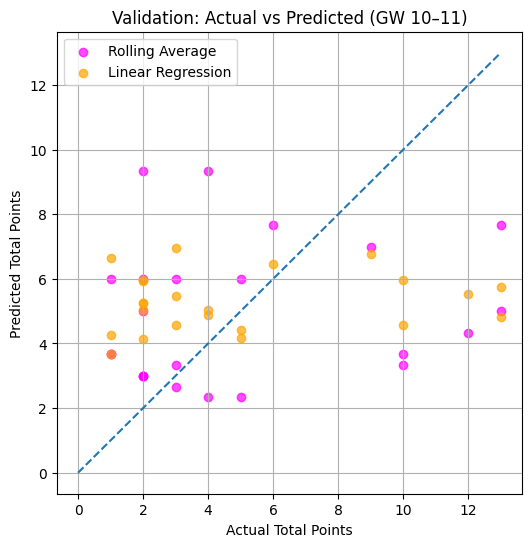

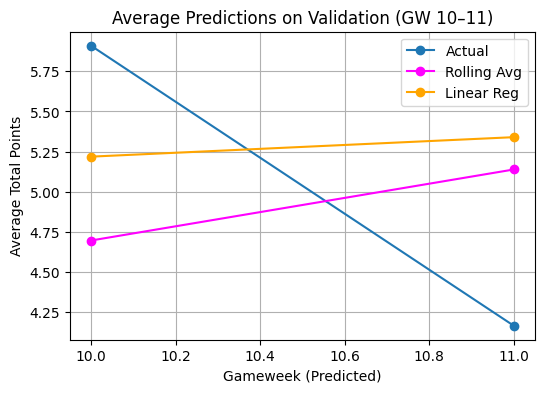

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

BASE_DIR = Path("..") / "output"

ROLLING_PATH = BASE_DIR / "models" / "baseline2" / "rolling_baseline_predictions.csv"
LINEAR_PATH  = BASE_DIR / "models" / "linreg2" / "linear_regression_predictions.csv"

df_roll = pd.read_csv(ROLLING_PATH, encoding="utf-8-sig")
df_lin  = pd.read_csv(LINEAR_PATH, encoding="utf-8-sig")

# Keep validation only
df_roll = df_roll[df_roll["Split"] == "Validation"]
df_lin  = df_lin[df_lin["Split"] == "Validation"]

# Merge
df_plot = df_roll.merge(
    df_lin,
    on=["Player UUID", "Prediction_GW"],
    suffixes=("_Rolling", "_Linear")
)

# PLOT 1 — Actual vs Predicted (Scatter)

plt.figure(figsize=(6, 6))

plt.scatter(
    df_plot["Total_Points_Actual_Rolling"],
    df_plot["Total_Points_Predicted_Rolling"],
    label="Rolling Average",
    color="magenta",
    alpha=0.7
)

plt.scatter(
    df_plot["Total_Points_Actual_Rolling"],
    df_plot["Total_Points_Predicted_Linear"],
    label="Linear Regression",
    color="orange",
    alpha=0.7
)

max_val = max(
    df_plot["Total_Points_Actual_Rolling"].max(),
    df_plot["Total_Points_Predicted_Linear"].max(),
    df_plot["Total_Points_Predicted_Rolling"].max()
)

plt.plot([0, max_val], [0, max_val], linestyle="--")

plt.xlabel("Actual Total Points")
plt.ylabel("Predicted Total Points")
plt.title("Validation: Actual vs Predicted (GW 10–11)")
plt.legend()
plt.grid(True)
plt.show()


# PLOT 2 — Average Prediction per GW
avg_df = (
    df_plot
    .groupby("Prediction_GW")
    .agg(
        Actual=("Total_Points_Actual_Rolling", "mean"),
        Rolling=("Total_Points_Predicted_Rolling", "mean"),
        Linear=("Total_Points_Predicted_Linear", "mean")
    )
    .reset_index()
)

plt.figure(figsize=(6, 4))

plt.plot(avg_df["Prediction_GW"], avg_df["Actual"], marker="o", label="Actual")
plt.plot(avg_df["Prediction_GW"], avg_df["Rolling"], marker="o", label="Rolling Avg", color="magenta")
plt.plot(avg_df["Prediction_GW"], avg_df["Linear"], marker="o", label="Linear Reg", color="orange")

plt.xlabel("Gameweek (Predicted)")
plt.ylabel("Average Total Points")
plt.title("Average Predictions on Validation (GW 10–11)")
plt.legend()
plt.grid(True)
plt.show()


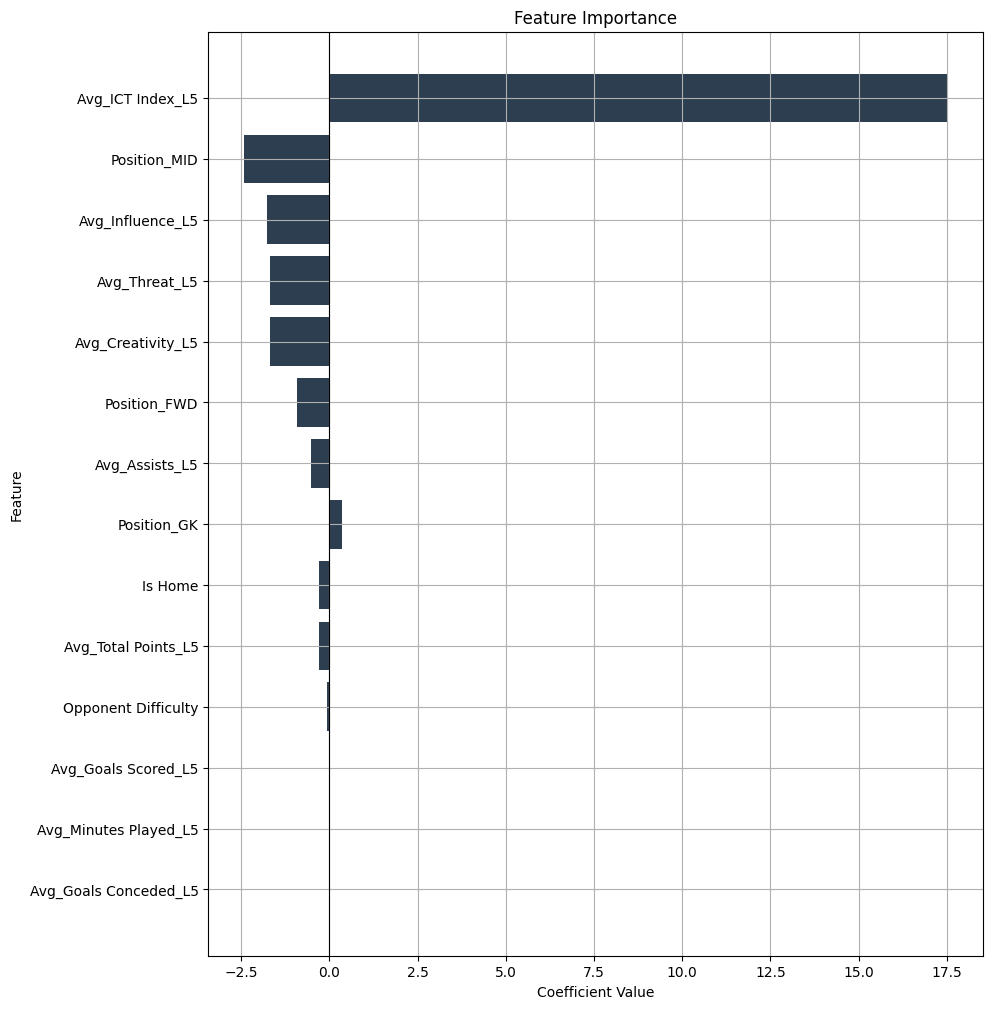

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

COEFF_PATH = Path("..") / "output" / "models" / "linreg2" / "coefficients.csv"

coeff_df = pd.read_csv(COEFF_PATH, encoding="utf-8-sig")

# Αφαιρούμε intercept
coeff_df = coeff_df[coeff_df["Feature"] != "Intercept"]

# Υπολογισμός απόλυτης τιμής για σωστή ταξινόμηση
coeff_df["AbsCoefficient"] = coeff_df["Coefficient"].abs()

# Ταξινόμηση (μικρά → μεγάλα για καθαρό plot)
coeff_df = coeff_df.sort_values("AbsCoefficient", ascending=True)

plt.figure(figsize=(10, 12))

plt.barh(
    coeff_df["Feature"],
    coeff_df["Coefficient"],
    color='#2C3E50'
)

plt.axvline(0, color="black", linewidth=0.8)

plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.title("Feature Importance")
plt.grid(True)
plt.show()


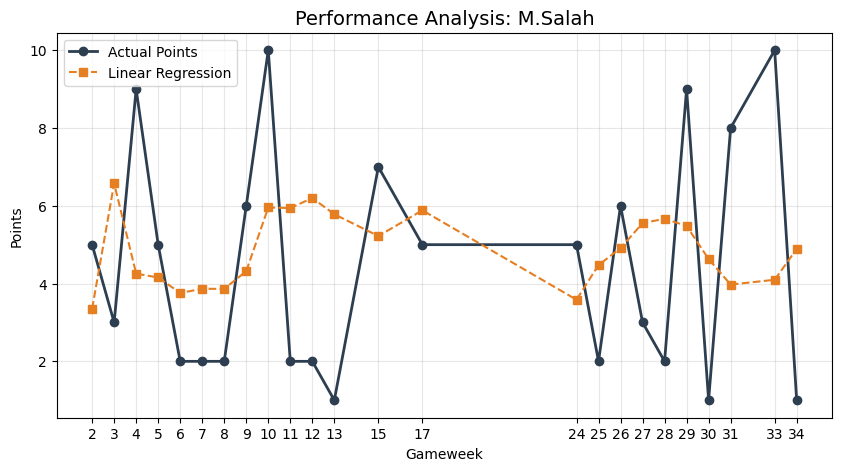

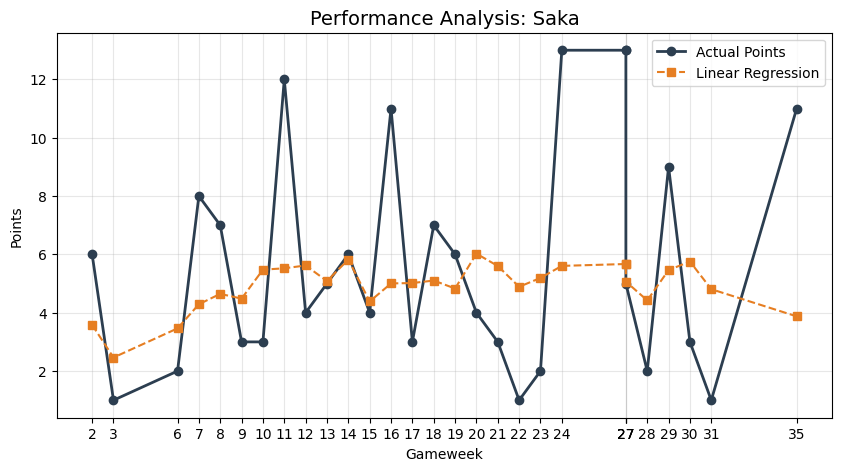

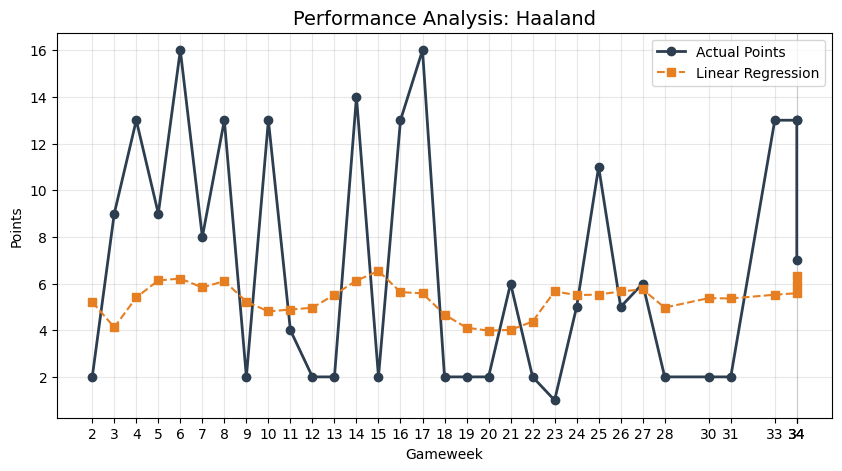

In [16]:
import pandas as pd
import matplotlib.pyplot as plt


df_preds = pd.read_csv("../output/models/linreg2/linear_regression_predictions.csv")


players_to_plot = ["M.Salah", "Saka", "Haaland"]

for player_name in players_to_plot:
    p_data = df_preds[df_preds["Web Name"] == player_name].sort_values("Prediction_GW")
    
    if p_data.empty:
        print(f" Player '{player_name}' not found in validation set.")
        continue
        
    # Δημιουργία γραφήματος
    plt.figure(figsize=(10, 5))
    
    # Actual Points (Μαύρο)
    plt.plot(p_data["Prediction_GW"], p_data["Total_Points_Actual"], 
             marker='o', label='Actual Points', color='#2C3E50', linewidth=2)
    
    # Linear Regression (Πορτοκαλί)
    plt.plot(p_data["Prediction_GW"], p_data["Total_Points_Predicted"], 
             marker='s', label='Linear Regression', linestyle='--', color='#E67E22')

    plt.title(f"Performance Analysis: {player_name}", fontsize=14)
    plt.xlabel("Gameweek")
    plt.ylabel("Points")
    plt.xticks(p_data["Prediction_GW"])
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

In [17]:

from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error
import pandas as pd
import numpy as np
from pathlib import Path

OUT_DIR_LASSO = Path("..") / "output" / "models" / "lasso"
OUT_DIR_LASSO.mkdir(parents=True, exist_ok=True)

print("Training Lasso Regression model...")

# 2. Training (alpha=0.1 as a starting point)
lasso_model = Lasso(alpha=0.1, random_state=42)
lasso_model.fit(X_train, y_train)

# 3. Predictions
y_train_pred_lasso = lasso_model.predict(X_train)
y_val_pred_lasso = lasso_model.predict(X_val)
y_all_pred_lasso = lasso_model.predict(X) # Predictions for the entire dataset

# 4. Metrics Calculation
mae_train_lasso = mean_absolute_error(y_train, y_train_pred_lasso)
mae_val_lasso = mean_absolute_error(y_val, y_val_pred_lasso)
rmse_train_lasso = np.sqrt(mean_squared_error(y_train, y_train_pred_lasso))
rmse_val_lasso = np.sqrt(mean_squared_error(y_val, y_val_pred_lasso))

print(f"Lasso Performance: MAE Validation = {mae_val_lasso:.4f}")

# 5. Update central performance file
update_model_performance(
    model_name="Lasso Regression (alpha=0.1)", 
    mae_train=mae_train_lasso, 
    mae_val=mae_val_lasso, 
    rmse_train=rmse_train_lasso, 
    rmse_val=rmse_val_lasso
)

# 6. Save Predictions
df_lasso_out = df_lr.copy()
df_lasso_out["Total_Points_Actual"] = df_lasso_out["Target_NextGW"]
df_lasso_out["Total_Points_Predicted"] = y_all_pred_lasso
df_lasso_out["Error(Actual-Predicted)"] = (
    df_lasso_out["Total_Points_Actual"] - df_lasso_out["Total_Points_Predicted"]
).abs()

keep_cols = [
    "Player UUID", "Player Name", "Web Name", 
    "Prediction_GW", "Total_Points_Actual", 
    "Total_Points_Predicted", "Error(Actual-Predicted)", "Split"
]

df_lasso_out[keep_cols].to_csv(
    OUT_DIR_LASSO / "lasso_predictions.csv", 
    index=False, 
    encoding="utf-8-sig"
)

# 7. Save Coefficients (coefficients.csv)
coeff_lasso = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lasso_model.coef_
}).sort_values("Coefficient", ascending=False)

intercept_lasso = pd.DataFrame([{
    "Feature": "Intercept",
    "Coefficient": lasso_model.intercept_
}])

final_coeffs_lasso = pd.concat([intercept_lasso, coeff_lasso], ignore_index=True)
final_coeffs_lasso.to_csv(
    OUT_DIR_LASSO / "coefficients.csv", 
    index=False, 
    encoding="utf-8-sig"
)

print(f"Lasso outputs saved to: {OUT_DIR_LASSO}")

# Inspection: Which features were zeroed out?
zero_coeffs = final_coeffs_lasso[final_coeffs_lasso["Coefficient"] == 0]
if not zero_coeffs.empty:
    print("\nImportant: Lasso zeroed out the following features:")
    print(zero_coeffs["Feature"].tolist())
else:
    print("\nLasso kept all features (no coefficients are 0).")

Training Lasso Regression model...
Lasso Performance: MAE Validation = 3.2652
 model_performance.csv updated (Overwrite): Lasso Regression (alpha=0.1)
Lasso outputs saved to: ..\output\models\lasso

Important: Lasso zeroed out the following features:
['Avg_Assists_L5', 'Avg_Goals Conceded_L5', 'Avg_Goals Scored_L5', 'Position_GK', 'Avg_ICT Index_L5', 'Is Home', 'Opponent Difficulty', 'Position_FWD']


In [18]:
import lightgbm as lgb
import optuna
from sklearn.metrics import mean_absolute_error, mean_squared_error
import pandas as pd
import numpy as np
from pathlib import Path

OUT_DIR_LGB = Path("..") / "output" / "models" / "lightgbm"
OUT_DIR_LGB.mkdir(parents=True, exist_ok=True)

def objective(trial):
    # Param search space optimized for small datasets
    params = {
        "objective": "regression_l1", # This tells LGBM to optimize for MAE!
        "metric": "mae",
        "verbosity": -1,
        "boosting_type": "gbdt",
        "random_state": 42,
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.1, log=True),
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
        "num_leaves": trial.suggest_int("num_leaves", 2, 31),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 50),
        "feature_fraction": trial.suggest_float("feature_fraction", 0.5, 1.0),
        "lambda_l1": trial.suggest_float("lambda_l1", 1e-8, 10.0, log=True),
        "lambda_l2": trial.suggest_float("lambda_l2", 1e-8, 10.0, log=True),
    }
    
    model = lgb.LGBMRegressor(**params)
    model.fit(X_train, y_train)
    
    preds = model.predict(X_val)
    return mean_absolute_error(y_val, preds)

print("🚀 Tuning LightGBM to take the #1 spot...")
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50) 

print(f"✅ Best MAE found: {study.best_trial.value:.4f}")

# Train the winning model
best_lgb = lgb.LGBMRegressor(**study.best_params, objective="regression_l1", random_state=42, verbosity=-1)
best_lgb.fit(X_train, y_train)

# Predictions
y_train_pred_lgb = best_lgb.predict(X_train)
y_val_pred_lgb = best_lgb.predict(X_val)
y_all_pred_lgb = best_lgb.predict(X)

# Metrics
mae_train_lgb = mean_absolute_error(y_train, y_train_pred_lgb)
mae_val_lgb = mean_absolute_error(y_val, y_val_pred_lgb)
rmse_train_lgb = np.sqrt(mean_squared_error(y_train, y_train_pred_lgb))
rmse_val_lgb = np.sqrt(mean_squared_error(y_val, y_val_pred_lgb))

# Update Performance
update_model_performance(
    model_name="LightGBM (Optimized)", 
    mae_train=mae_train_lgb, 
    mae_val=mae_val_lgb, 
    rmse_train=rmse_train_lgb, 
    rmse_val=rmse_val_lgb
)

# Save Outputs
df_lgb_out = df_lr.copy()
df_lgb_out["Total_Points_Actual"] = df_lgb_out["Target_NextGW"]
df_lgb_out["Total_Points_Predicted"] = y_all_pred_lgb
df_lgb_out["Error(Actual-Predicted)"] = (df_lgb_out["Total_Points_Actual"] - df_lgb_out["Total_Points_Predicted"]).abs()

df_lgb_out[keep_cols].to_csv(OUT_DIR_LGB / "lgb_predictions.csv", index=False, encoding="utf-8-sig")

print(f"Model saved. Check the summary panel to see if LightGBM moved to 1st place!")

🚀 Tuning LightGBM to take the #1 spot...

[I 2026-05-14 13:17:52,099] A new study created in memory with name: no-name-eb38bb5f-5ef1-494e-87e4-90569b93329e


[I 2026-05-14 13:17:53,976] Trial 0 finished with value: 3.15218342601113 and parameters: {'learning_rate': 0.022983351719577556, 'n_estimators': 496, 'num_leaves': 5, 'max_depth': 12, 'min_child_samples': 24, 'feature_fraction': 0.8094824048909173, 'lambda_l1': 0.001831849601292922, 'lambda_l2': 1.4790368009800997e-08}. Best is trial 0 with value: 3.15218342601113.
[I 2026-05-14 13:17:54,050] Trial 1 finished with value: 2.5086928198385117 and parameters: {'learning_rate': 0.008271101945265502, 'n_estimators': 976, 'num_leaves': 8, 'max_depth': 3, 'min_child_samples': 6, 'feature_fraction': 0.8501670453450896, 'lambda_l1': 1.6532934026507844e-06, 'lambda_l2': 1.3418782458693857e-06}. Best is trial 1 with value: 2.5086928198385117.
[I 2026-05-14 13:17:54,270] Trial 2 finished with value: 2.86956739038594 and parameters: {'learning_rate': 0.011719025387222996, 'n_estimators': 881, 'num_leaves': 17, 'max_depth': 12, 'min_child_samples': 10, 'feature_fraction': 0.791573811371135, 'lambda_

✅ Best MAE found: 2.5087
 model_performance.csv updated (Overwrite): LightGBM (Optimized)
Model saved. Check the summary panel to see if LightGBM moved to 1st place!


In [19]:
from sklearn.ensemble import RandomForestRegressor

# 1. Define output directory
OUT_DIR_RF = Path("..") / "output" / "models" / "random_forest"
OUT_DIR_RF.mkdir(parents=True, exist_ok=True)

print("Training Random Forest Regressor...")

# 2. Training
rf_model = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# 3. Predictions
y_train_pred_rf = rf_model.predict(X_train)
y_val_pred_rf = rf_model.predict(X_val)
y_all_pred_rf = rf_model.predict(X)

# 4. Metrics
mae_train_rf = mean_absolute_error(y_train, y_train_pred_rf)
mae_val_rf = mean_absolute_error(y_val, y_val_pred_rf)
rmse_train_rf = np.sqrt(mean_squared_error(y_train, y_train_pred_rf))
rmse_val_rf = np.sqrt(mean_squared_error(y_val, y_val_pred_rf))

print(f"Random Forest Performance: MAE Validation = {mae_val_rf:.4f}")

# 5. Update performance file
update_model_performance(
    model_name="Random Forest", 
    mae_train=mae_train_rf, 
    mae_val=mae_val_rf, 
    rmse_train=rmse_train_rf, 
    rmse_val=rmse_val_rf
)

# 6. Save outputs
df_rf_out = df_lr.copy()
df_rf_out["Total_Points_Actual"] = df_rf_out["Target_NextGW"]
df_rf_out["Total_Points_Predicted"] = y_all_pred_rf
df_rf_out["Error(Actual-Predicted)"] = (df_rf_out["Total_Points_Actual"] - df_rf_out["Total_Points_Predicted"]).abs()

df_rf_out[keep_cols].to_csv(OUT_DIR_RF / "rf_predictions.csv", index=False, encoding="utf-8-sig")

# 7. Importance
importance_rf = pd.DataFrame({"Feature": X.columns, "Importance": rf_model.feature_importances_}).sort_values("Importance", ascending=False)
importance_rf.to_csv(OUT_DIR_RF / "feature_importance.csv", index=False, encoding="utf-8-sig")

print(f"Random Forest outputs saved to: {OUT_DIR_RF}")

Training Random Forest Regressor...
Random Forest Performance: MAE Validation = 3.3103
 model_performance.csv updated (Overwrite): Random Forest
Random Forest outputs saved to: ..\output\models\random_forest


In [20]:

import optuna
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. Define output directory
OUT_DIR_GBM = Path("..") / "output" / "models" / "gbm"
OUT_DIR_GBM.mkdir(parents=True, exist_ok=True)

def objective(trial):
    # Defining the search space for hyperparameters
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 7),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0)
    }
    
    model = GradientBoostingRegressor(**params, random_state=42)
    model.fit(X_train, y_train)
    
    preds = model.predict(X_val)
    return mean_absolute_error(y_val, preds)

print("Starting Optuna optimization for GBM...")
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=30) # 30 trials is a good balance for speed/accuracy

print(f"Best trial: {study.best_trial.value:.4f}")
print("Best hyperparameters:", study.best_params)

# 2. Training the final model with best parameters
best_gbm = GradientBoostingRegressor(**study.best_params, random_state=42)
best_gbm.fit(X_train, y_train)

# 3. Predictions
y_train_pred_gbm = best_gbm.predict(X_train)
y_val_pred_gbm = best_gbm.predict(X_val)
y_all_pred_gbm = best_gbm.predict(X)

# 4. Metrics
mae_train_gbm = mean_absolute_error(y_train, y_train_pred_gbm)
mae_val_gbm = mean_absolute_error(y_val, y_val_pred_gbm)
rmse_train_gbm = np.sqrt(mean_squared_error(y_train, y_train_pred_gbm))
rmse_val_gbm = np.sqrt(mean_squared_error(y_val, y_val_pred_gbm))

print(f"Final GBM Performance: MAE Validation = {mae_val_gbm:.4f}")

# 5. Update performance file
update_model_performance(
    model_name="GBM (Optuna Optimized)", 
    mae_train=mae_train_gbm, 
    mae_val=mae_val_gbm, 
    rmse_train=rmse_train_gbm, 
    rmse_val=rmse_val_gbm
)

# 6. Save outputs
df_gbm_out = df_lr.copy()
df_gbm_out["Total_Points_Actual"] = df_gbm_out["Target_NextGW"]
df_gbm_out["Total_Points_Predicted"] = y_all_pred_gbm
df_gbm_out["Error(Actual-Predicted)"] = (df_gbm_out["Total_Points_Actual"] - df_gbm_out["Total_Points_Predicted"]).abs()

df_gbm_out[keep_cols].to_csv(OUT_DIR_GBM / "gbm_predictions.csv", index=False, encoding="utf-8-sig")

# 7. Importance
importance_gbm = pd.DataFrame({"Feature": X.columns, "Importance": best_gbm.feature_importances_}).sort_values("Importance", ascending=False)
importance_gbm.to_csv(OUT_DIR_GBM / "feature_importance.csv", index=False, encoding="utf-8-sig")

print(f"GBM outputs saved to: {OUT_DIR_GBM}")

[I 2026-05-14 13:17:59,537] A new study created in memory with name: no-name-ea18b9fc-8b0b-4e9d-b44a-05814534be77


Starting Optuna optimization for GBM...


[I 2026-05-14 13:17:59,776] Trial 0 finished with value: 3.5423512492438074 and parameters: {'n_estimators': 256, 'learning_rate': 0.04845861034631488, 'max_depth': 5, 'min_samples_split': 9, 'subsample': 0.7341076492973904}. Best is trial 0 with value: 3.5423512492438074.
[I 2026-05-14 13:17:59,935] Trial 1 finished with value: 3.340745331663347 and parameters: {'n_estimators': 171, 'learning_rate': 0.12590260328261216, 'max_depth': 4, 'min_samples_split': 8, 'subsample': 0.8786296765960101}. Best is trial 1 with value: 3.340745331663347.
[I 2026-05-14 13:18:00,126] Trial 2 finished with value: 3.4310413686149643 and parameters: {'n_estimators': 206, 'learning_rate': 0.08404046429442627, 'max_depth': 4, 'min_samples_split': 8, 'subsample': 0.9225808504078422}. Best is trial 1 with value: 3.340745331663347.
[I 2026-05-14 13:18:00,269] Trial 3 finished with value: 3.245841239775083 and parameters: {'n_estimators': 118, 'learning_rate': 0.0518654730273098, 'max_depth': 6, 'min_samples_sp

Best trial: 3.0897
Best hyperparameters: {'n_estimators': 235, 'learning_rate': 0.016473660690123893, 'max_depth': 6, 'min_samples_split': 4, 'subsample': 0.8391476134606665}
Final GBM Performance: MAE Validation = 3.0897
 model_performance.csv updated (Overwrite): GBM (Optuna Optimized)
GBM outputs saved to: ..\output\models\gbm


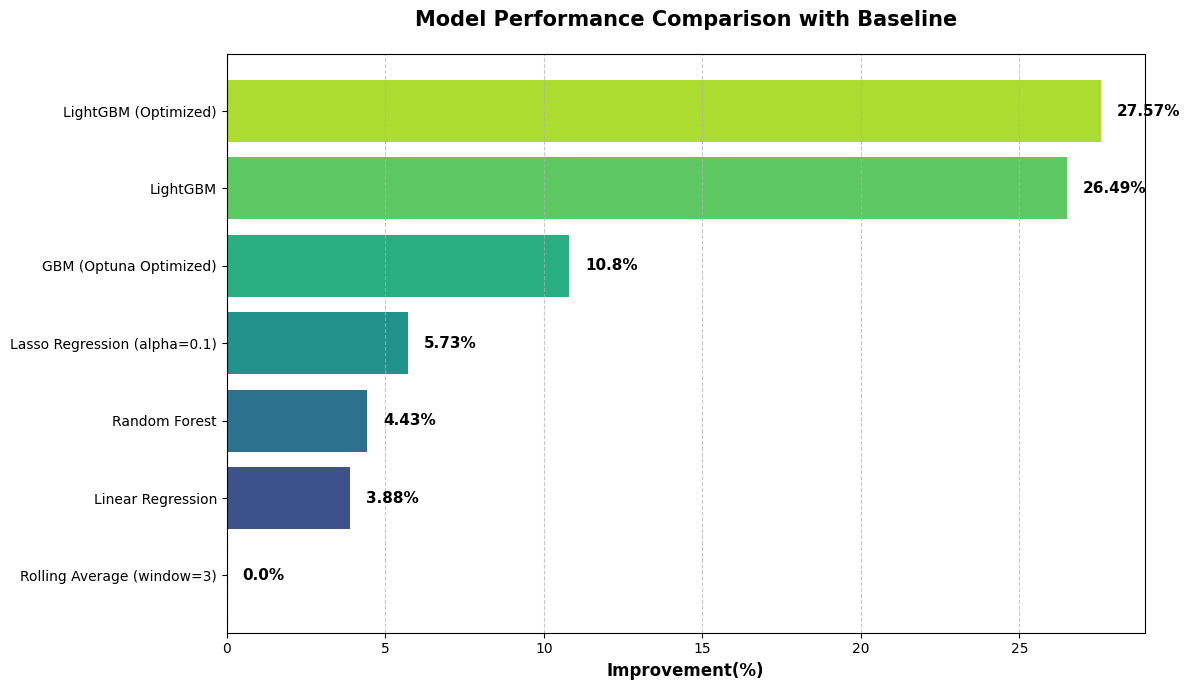

Final comparison chart saved to: ../output/models/model_comparison_improvement.png


In [21]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# 1. Load the performance data
perf_path = Path("../output/models/models_performance.csv")
if perf_path.exists():
    df_perf = pd.read_csv(perf_path)
    
    # Sort by improvement for better visualization
    df_perf = df_perf.sort_values("Improvement_vs_Baseline (%)", ascending=True)

    # 2. Create the Bar Chart
    plt.figure(figsize=(12, 7))
    
    # Use a nice color palette
    colors = sns.color_palette("viridis", len(df_perf))
    
    bars = plt.barh(df_perf["Model"], df_perf["Improvement_vs_Baseline (%)"], color=colors)

    # Add labels and styling
    plt.xlabel("Improvement(%)", fontsize=12, fontweight='bold')
    plt.title("Model Performance Comparison with Baseline", fontsize=15, fontweight='bold', pad=20)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    
    # Add the percentage values on the bars
    for bar in bars:
        width = bar.get_width()
        plt.text(width + 0.5, bar.get_y() + bar.get_height()/2, 
                 f'{width}%', va='center', fontsize=11, fontweight='bold')

    # Highlight the winner
    plt.tight_layout()
    
    # 3. Save the final plot
    plt.savefig("../output/models/model_comparison_improvement.png", dpi=300)
    plt.show()
    
    print("Final comparison chart saved to: ../output/models/model_comparison_improvement.png")
else:
    print("Error: models_performance.csv not found. Please run your models first.")

In [22]:
import pandas as pd
from pathlib import Path
from IPython.display import display

perf_path = Path("../output/models/models_performance.csv")

if perf_path.exists():
    # Load the performance data
    df_perf = pd.read_csv(perf_path)
    
    # --- CLEANUP STEP ---
    # 1. Drop the old unoptimized LightGBM row
    df_perf = df_perf[df_perf["Model"] != "LightGBM"].copy()
    
    # 2. Rename the optimized one to just "LightGBM"
    df_perf["Model"] = df_perf["Model"].replace({"LightGBM (Optimized)": "LightGBM"})
    
    # 3. Save the cleaned dataframe back to the CSV so the old row is gone forever
    df_perf.to_csv(perf_path, index=False, encoding="utf-8-sig")
    # --------------------
    
    # Sort by Validation MAE (best performing at the top)
    df_perf = df_perf.sort_values("MAE_Validation", ascending=True).reset_index(drop=True)
    
    print("## 🏆 Model Performance Summary Panel")
    print("-" * 50)
    
    # Style the dataframe for a "panel" look in Jupyter
    styled_df = df_perf.style.background_gradient(
        subset=["MAE_Validation", "RMSE_Validation"], 
        cmap="RdYlGn_r"  # Green for lower (better) values, Red for higher
    ).format({
        "MAE_Train": "{:.4f}",
        "MAE_Validation": "{:.4f}",
        "RMSE_Train": "{:.4f}",
        "RMSE_Validation": "{:.4f}",
        "Improvement_vs_Baseline (%)": "{:.2f}%"
    })
    
    display(styled_df)
    
    # Quick insight printout
    best_model = df_perf.iloc[0]["Model"]
    best_mae = df_perf.iloc[0]["MAE_Validation"]
    print(f"\n✨ Current Leader: **{best_model}** with an MAE of **{best_mae:.4f}**")
    
else:
    print("❌ Performance file not found. Make sure you've run at least one model cell!")

## 🏆 Model Performance Summary Panel
--------------------------------------------------


,Model,MAE_Train,MAE_Validation,RMSE_Train,RMSE_Validation,Improvement_vs_Baseline (%)
0,LightGBM,2.3002,2.5087,3.6374,3.4392,27.57%
1,GBM (Optuna Optimized),1.5801,3.0897,1.9980,3.7655,10.80%
2,Lasso Regression (alpha=0.1),3.1660,3.2652,3.9830,3.8616,5.73%
3,Random Forest,2.7251,3.3103,3.3641,4.0661,4.43%
4,Linear Regression,3.1153,3.3293,3.9341,3.9312,3.88%
5,Rolling Average (window=3),3.5129,3.4638,4.6769,4.2330,0.00%



✨ Current Leader: **LightGBM** with an MAE of **2.5087**


✅ White Theme Presentation chart successfully saved to: ../output/models/mae_validation_chart_white.png


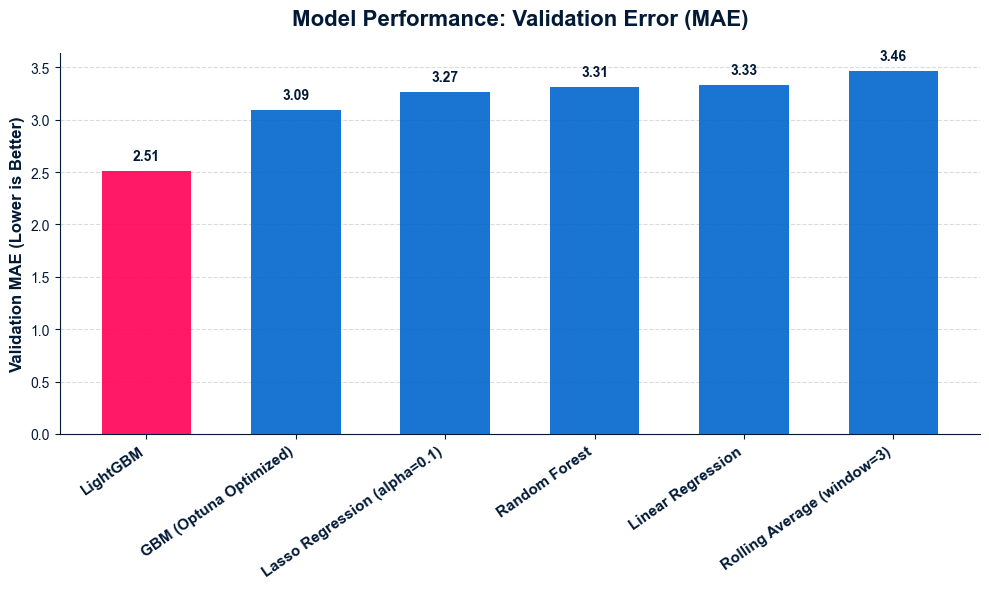

In [25]:
# %% [Cell: Validation MAE Bar Chart Generation - WHITE THEME]
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

perf_path = Path("../output/models/models_performance.csv")

if perf_path.exists():
    # Load the data
    df_perf = pd.read_csv(perf_path)
    
    # Sort by Validation MAE ascending (Best/Lowest MAE will be first)
    df_perf = df_perf.sort_values("MAE_Validation", ascending=True).reset_index(drop=True)
    
    # Extract data for plotting
    models = df_perf['Model'].tolist()
    val_mae = df_perf['MAE_Validation'].tolist()

    # --- EXPERT CHART STYLING (WHITE THEME) ---
    plt.rcParams.update({'font.family': 'sans-serif', 'font.sans-serif': ['Arial', 'DejaVu Sans']})
    
    # Set crisp white background
    slide_bg_color = '#ffffff'
    font_color = '#021a36'  # Dark Navy for contrast
    
    fig, ax = plt.subplots(figsize=(10, 6), facecolor=slide_bg_color)
    ax.set_facecolor(slide_bg_color)

    x = np.arange(len(models))
    
    # Highlight the Champion in Pink, rest in Deep Blue (Readable on white)
    colors = ['#ff0055' if i == 0 else '#0066cc' for i in range(len(models))]

    # Plot the single bar chart for Validation MAE
    bars = ax.bar(x, val_mae, width=0.6, color=colors, alpha=0.9)

    # Text and Labels
    ax.set_ylabel('Validation MAE (Lower is Better)', color=font_color, fontsize=12, fontweight='bold')
    ax.set_title('Model Performance: Validation Error (MAE)', 
                 color=font_color, fontsize=16, pad=20, fontweight='bold')
    
    # Axis formatting
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=35, ha='right', color=font_color, fontsize=11, fontweight='bold')
    ax.tick_params(axis='y', colors=font_color)
    ax.tick_params(axis='x', colors=font_color)

    # Minimalist Grid and Spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color(font_color)
    ax.spines['bottom'].set_color(font_color)
    ax.yaxis.grid(True, linestyle='--', alpha=0.3, color='#888888')
    ax.set_axisbelow(True)

    # Add data labels directly on top of the bars
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 6),  # 6 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', color=font_color, fontsize=10, fontweight='bold')

    # Save out in high resolution
    plt.tight_layout()
    save_path = "../output/models/mae_validation_chart_white.png"
    plt.savefig(save_path, dpi=300, facecolor=fig.get_facecolor(), edgecolor='none')
    print(f"✅ White Theme Presentation chart successfully saved to: {save_path}")
    
    plt.show()

else:
    print("❌ Performance file not found. Ensure models_performance.csv exists.")